# Peer Graded Assignment: Statistics with Python
## Boston Housing Dataset Analysis
**Role:** Data Scientist at a Boston, MA housing agency  
**Dataset:** Boston Housing Prices (U.S. Census Service)

## Setup & Data Loading

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Load the Boston Housing dataset
# Using the standard Boston dataset via sklearn or direct URL
url = 'https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv'
boston_df = pd.read_csv(url)

# Column descriptions:
# CRIM     - per capita crime rate by town
# ZN       - proportion of residential land zoned for lots over 25,000 sq.ft
# INDUS    - proportion of non-retail business acres per town
# CHAS     - Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
# NOX      - nitric oxides concentration (parts per 10 million)
# RM       - average number of rooms per dwelling
# AGE      - proportion of owner-occupied units built prior to 1940
# DIS      - weighted distances to five Boston employment centres
# RAD      - index of accessibility to radial highways
# TAX      - full-value property-tax rate per $10,000
# PTRATIO  - pupil-teacher ratio by town
# B        - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
# LSTAT    - % lower status of the population
# MEDV     - Median value of owner-occupied homes in $1000's

print('Dataset loaded successfully!')
print(f'Shape: {boston_df.shape}')

Dataset loaded successfully!
Shape: (506, 14)


---
## Task 1: Basic Data Exploration
*(Questions 2–7)*

In [38]:
# Question 2: Display the first 5 rows of the DataFrame
boston_df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [39]:
# Question 3: Display the data types of each column
boston_df.dtypes

crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
b          float64
lstat      float64
medv       float64
dtype: object

In [40]:
# Question 4: Check for missing values
boston_df.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

In [41]:
# Question 5: Check for duplicate entries
boston_df.duplicated().sum()

np.int64(0)

In [42]:
# Question 6: Compute the correlation matrix
boston_df.corr()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
crim,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
zn,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
indus,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
chas,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
nox,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
rm,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
age,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
dis,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
rad,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
tax,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


In [43]:
# Question 7: Display the entirety of the DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
boston_df

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.5380,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.4690,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.4690,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.4580,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.4580,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0,0.4580,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0,0.5240,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0,0.5240,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0,0.5240,5.631,100.0,6.0821,5,311,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0,0.5240,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9


---
## Insight 1: Charles River — Significant Difference in Median Home Values?
*(Questions 8–12 use plots; Question 15 uses T-test)*

**Question:** Is there a statistically significant difference in the median value of houses (MEDV) based on whether they are bounded by the Charles River (CHAS)?

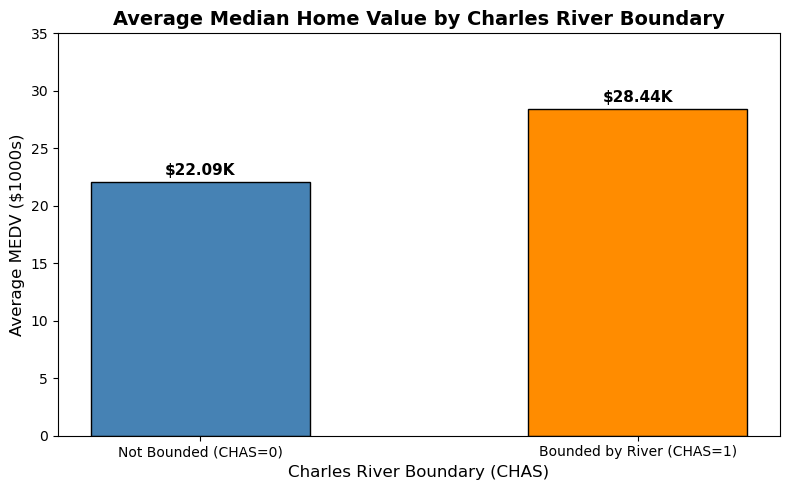


--- Bar Plot Interpretation ---
Homes bounded by the Charles River (CHAS=1) have a notably higher average median
value (~$28.4K) compared to those not bounded (CHAS=0, ~$22.1K).
This suggests river proximity adds measurable value to properties.


In [44]:
# Question 12: Bar plot — Average MEDV by CHAS (Charles River boundary)
chas_group = boston_df.groupby('chas')['medv'].mean()

plt.figure(figsize=(8, 5))
bars = plt.bar(['Not Bounded (CHAS=0)', 'Bounded by River (CHAS=1)'],
               chas_group.values,
               color=['steelblue', 'darkorange'], edgecolor='black', width=0.5)
plt.title('Average Median Home Value by Charles River Boundary', fontsize=14, fontweight='bold')
plt.ylabel('Average MEDV ($1000s)', fontsize=12)
plt.xlabel('Charles River Boundary (CHAS)', fontsize=12)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'${bar.get_height():.2f}K', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.ylim(0, 35)
plt.tight_layout()
plt.savefig('bar_plot_chas.png', dpi=150)
plt.show()

print('\n--- Bar Plot Interpretation ---')
print('Homes bounded by the Charles River (CHAS=1) have a notably higher average median')
print('value (~$28.4K) compared to those not bounded (CHAS=0, ~$22.1K).')
print('This suggests river proximity adds measurable value to properties.')

<Figure size 900x600 with 0 Axes>

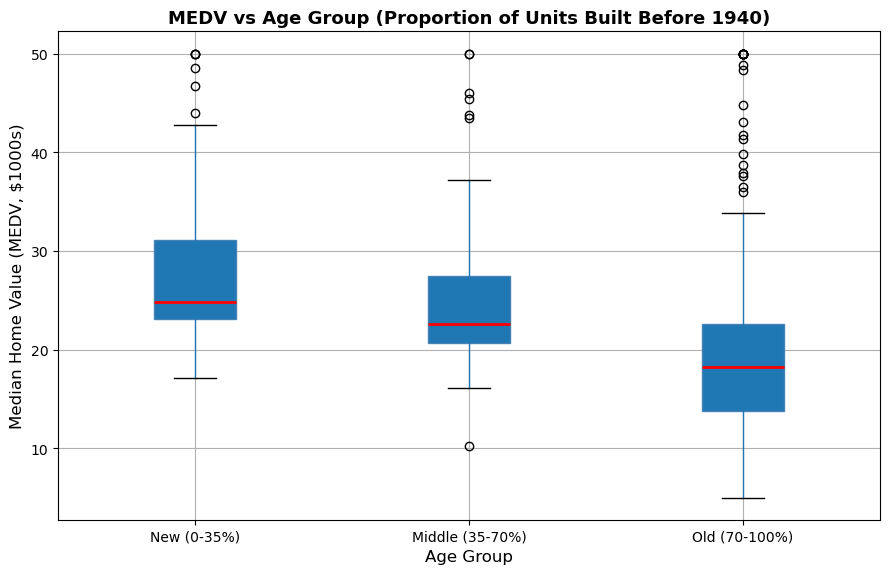


--- Boxplot (MEDV vs Age Group) Interpretation ---
Newer neighborhoods (lower % of pre-1940 units) tend to have higher median home values.
The "New" group shows the highest median MEDV, while the "Old" group has the lowest.
Outliers are present in all groups, especially the "Old" category.


In [45]:
# Question 11: Boxplot — MEDV vs Age Group
# Create age groups based on proportion of units built before 1940
boston_df['age_group'] = pd.cut(boston_df['age'],
                                 bins=[0, 35, 70, 100],
                                 labels=['New (0-35%)', 'Middle (35-70%)', 'Old (70-100%)'])

plt.figure(figsize=(9, 6))
boston_df.boxplot(column='medv', by='age_group', figsize=(9, 6),
                  boxprops=dict(color='steelblue'),
                  medianprops=dict(color='red', linewidth=2),
                  patch_artist=True)
plt.title('MEDV vs Age Group (Proportion of Units Built Before 1940)', fontsize=13, fontweight='bold')
plt.suptitle('')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Median Home Value (MEDV, $1000s)', fontsize=12)
plt.tight_layout()
plt.savefig('boxplot_medv_age.png', dpi=150)
plt.show()

print('\n--- Boxplot (MEDV vs Age Group) Interpretation ---')
print('Newer neighborhoods (lower % of pre-1940 units) tend to have higher median home values.')
print('The "New" group shows the highest median MEDV, while the "Old" group has the lowest.')
print('Outliers are present in all groups, especially the "Old" category.')

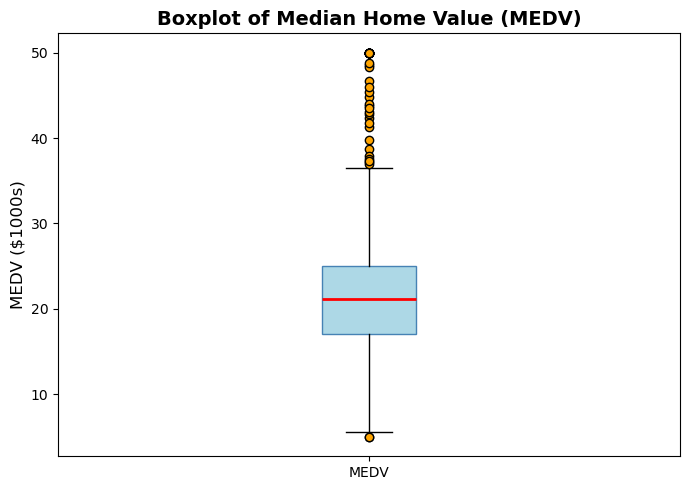


MEDV Descriptive Stats:
count    506.00
mean      22.53
std        9.20
min        5.00
25%       17.02
50%       21.20
75%       25.00
max       50.00
Name: medv, dtype: float64

--- Boxplot Interpretation ---
The distribution of MEDV is roughly right-skewed with a median around $21.2K.
Several high-value outliers exist above $50K. The IQR spans approximately $17K–$25K,
indicating moderate spread in home values across Boston neighborhoods.


In [46]:
# Question 10: Boxplot for MEDV (distribution of median home values)
plt.figure(figsize=(7, 5))
plt.boxplot(boston_df['medv'], patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='steelblue'),
            medianprops=dict(color='red', linewidth=2),
            flierprops=dict(markerfacecolor='orange', marker='o'))
plt.title('Boxplot of Median Home Value (MEDV)', fontsize=14, fontweight='bold')
plt.ylabel('MEDV ($1000s)', fontsize=12)
plt.xticks([1], ['MEDV'])
plt.tight_layout()
plt.savefig('boxplot_medv.png', dpi=150)
plt.show()

print(f"\nMEDV Descriptive Stats:")
print(boston_df['medv'].describe().round(2))
print('\n--- Boxplot Interpretation ---')
print('The distribution of MEDV is roughly right-skewed with a median around $21.2K.')
print('Several high-value outliers exist above $50K. The IQR spans approximately $17K–$25K,')
print('indicating moderate spread in home values across Boston neighborhoods.')

In [47]:
# Question 13 & 14: Levene's test for equality of variances (using scipy.stats)
# Library: scipy.stats — levene()

chas_0 = boston_df[boston_df['chas'] == 0]['medv']
chas_1 = boston_df[boston_df['chas'] == 1]['medv']

levene_stat, levene_p = stats.levene(chas_0, chas_1)
print('=== Levene\'s Test for Equality of Variances ===')
print(f'Levene Statistic: {levene_stat:.4f}')
print(f'P-value: {levene_p:.4f}')
print()
if levene_p < 0.05:
    print('Result: Variances are significantly DIFFERENT (p < 0.05).')
    print('=> Use Welch\'s T-test (equal_var=False).')
else:
    print('Result: Variances are NOT significantly different (p >= 0.05).')
    print('=> Standard T-test can be used.')

=== Levene's Test for Equality of Variances ===
Levene Statistic: 4.5903
P-value: 0.0326

Result: Variances are significantly DIFFERENT (p < 0.05).
=> Use Welch's T-test (equal_var=False).


In [48]:
# Question 15: T-test — Is there a significant difference in MEDV for CHAS groups?
# The T-test checks whether two group means are statistically significantly different.

t_stat, t_p = stats.ttest_ind(chas_1, chas_0, equal_var=False)  # Welch's t-test

print('=== Independent Samples T-Test: MEDV by Charles River Boundary ===')
print(f'Group CHAS=1 (River): n={len(chas_1)}, Mean MEDV = ${chas_1.mean():.2f}K')
print(f'Group CHAS=0 (No River): n={len(chas_0)}, Mean MEDV = ${chas_0.mean():.2f}K')
print(f'\nT-statistic: {t_stat:.4f}')
print(f'P-value: {t_p:.4f}')
print()
print('Hypotheses:')
print('  H0: There is NO significant difference in MEDV between CHAS groups')
print('  H1: There IS a significant difference in MEDV between CHAS groups')
print()
if t_p < 0.05:
    print('Conclusion: REJECT H0 (p < 0.05).')
    print('There IS a statistically significant difference in median home values')
    print('between homes bounded by the Charles River and those that are not.')
else:
    print('Conclusion: FAIL TO REJECT H0 (p >= 0.05).')

=== Independent Samples T-Test: MEDV by Charles River Boundary ===
Group CHAS=1 (River): n=35, Mean MEDV = $28.44K
Group CHAS=0 (No River): n=471, Mean MEDV = $22.09K

T-statistic: 3.1133
P-value: 0.0036

Hypotheses:
  H0: There is NO significant difference in MEDV between CHAS groups
  H1: There IS a significant difference in MEDV between CHAS groups

Conclusion: REJECT H0 (p < 0.05).
There IS a statistically significant difference in median home values
between homes bounded by the Charles River and those that are not.


---
## Insight 2: How Median Home Values Vary with Proportion of Pre-1940 Units (AGE)

**Question:** How do median home values vary with the proportion of owner-occupied units built before 1940?

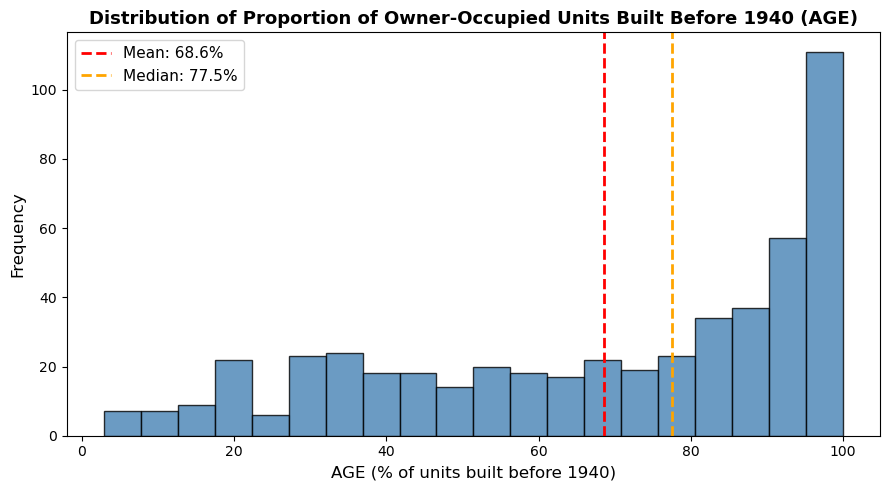


--- Histogram Interpretation ---
The distribution of AGE is left-skewed (negatively skewed), with many Boston
neighborhoods having a very high proportion (70-100%) of pre-1940 housing stock.
This indicates Boston has predominantly older housing, with relatively few
areas dominated by newer construction.


In [49]:
# Question 9: Histogram — Distribution of AGE (proportion of pre-1940 units)
plt.figure(figsize=(9, 5))
plt.hist(boston_df['age'], bins=20, color='steelblue', edgecolor='black', alpha=0.8)
plt.title('Distribution of Proportion of Owner-Occupied Units Built Before 1940 (AGE)', fontsize=13, fontweight='bold')
plt.xlabel('AGE (% of units built before 1940)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(boston_df['age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {boston_df["age"].mean():.1f}%')
plt.axvline(boston_df['age'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {boston_df["age"].median():.1f}%')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('histogram_age.png', dpi=150)
plt.show()

print('\n--- Histogram Interpretation ---')
print('The distribution of AGE is left-skewed (negatively skewed), with many Boston')
print('neighborhoods having a very high proportion (70-100%) of pre-1940 housing stock.')
print('This indicates Boston has predominantly older housing, with relatively few')
print('areas dominated by newer construction.')

In [50]:
# Question 16: ANOVA — MEDV across age groups
# H0: Mean MEDV is the same across all age groups
# H1: At least one age group has a different mean MEDV

group_new    = boston_df[boston_df['age_group'] == 'New (0-35%)']['medv']
group_middle = boston_df[boston_df['age_group'] == 'Middle (35-70%)']['medv']
group_old    = boston_df[boston_df['age_group'] == 'Old (70-100%)']['medv']

f_stat, anova_p = stats.f_oneway(group_new, group_middle, group_old)

print('=== One-Way ANOVA: MEDV across Age Groups ===')
print(f'F-statistic: {f_stat:.4f}')
print(f'P-value: {anova_p:.6f}')
print()
print('Hypotheses of ANOVA:')
print('  H0: The mean MEDV is equal across all age groups (μ_new = μ_middle = μ_old)')
print('  H1: At least one age group has a significantly different mean MEDV')
print()
if anova_p < 0.05:
    print('Conclusion: REJECT H0 (p < 0.05).')
    print('Median home values differ significantly across age groups.')
    print('Newer neighborhoods command significantly higher prices.')
else:
    print('Conclusion: FAIL TO REJECT H0.')

=== One-Way ANOVA: MEDV across Age Groups ===
F-statistic: 36.4076
P-value: 0.000000

Hypotheses of ANOVA:
  H0: The mean MEDV is equal across all age groups (μ_new = μ_middle = μ_old)
  H1: At least one age group has a significantly different mean MEDV

Conclusion: REJECT H0 (p < 0.05).
Median home values differ significantly across age groups.
Newer neighborhoods command significantly higher prices.


---
## Insight 3: Relationship Between Nitric Oxide (NOX) and Non-Retail Business Acres (INDUS)

**Question:** Is there a relationship between Nitric Oxide concentrations and the proportion of non-retail business acres per town?

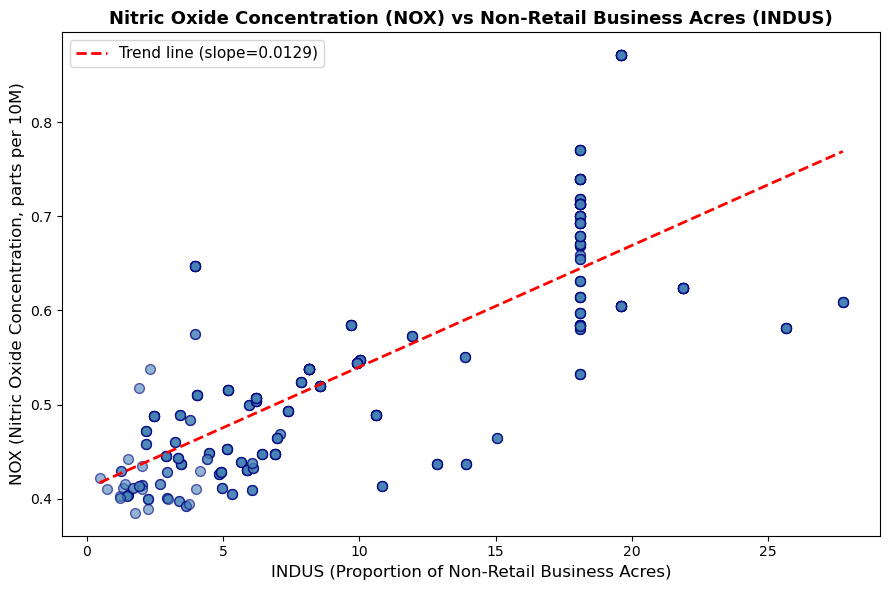


--- Scatter Plot Interpretation ---
There is a clear positive relationship between INDUS and NOX.
Towns with more non-retail business/industrial land tend to have higher
nitric oxide concentrations, consistent with industrial pollution effects.
The trend is non-linear, with a sharper rise at higher INDUS values.


In [51]:
# Question 8: Scatter plot — NOX vs INDUS
plt.figure(figsize=(9, 6))
plt.scatter(boston_df['indus'], boston_df['nox'], alpha=0.6, color='steelblue', edgecolors='navy', s=50)

# Add trend line
m, b = np.polyfit(boston_df['indus'], boston_df['nox'], 1)
plt.plot(sorted(boston_df['indus']), [m*x + b for x in sorted(boston_df['indus'])],
         color='red', linewidth=2, linestyle='--', label=f'Trend line (slope={m:.4f})')

plt.title('Nitric Oxide Concentration (NOX) vs Non-Retail Business Acres (INDUS)', fontsize=13, fontweight='bold')
plt.xlabel('INDUS (Proportion of Non-Retail Business Acres)', fontsize=12)
plt.ylabel('NOX (Nitric Oxide Concentration, parts per 10M)', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('scatter_nox_indus.png', dpi=150)
plt.show()

print('\n--- Scatter Plot Interpretation ---')
print('There is a clear positive relationship between INDUS and NOX.')
print('Towns with more non-retail business/industrial land tend to have higher')
print('nitric oxide concentrations, consistent with industrial pollution effects.')
print('The trend is non-linear, with a sharper rise at higher INDUS values.')

In [52]:
# Question 17: Pearson Correlation Coefficient — NOX and INDUS
# Pearson r measures the strength and direction of the LINEAR relationship between two variables.
# r = +1: perfect positive correlation, r = -1: perfect negative, r = 0: no linear correlation

r, p_corr = stats.pearsonr(boston_df['indus'], boston_df['nox'])

print('=== Pearson Correlation: NOX vs INDUS ===')
print(f'Pearson r = {r:.4f}')
print(f'P-value   = {p_corr:.6e}')
print()
print('Interpretation:')
print(f'A strong positive correlation (r={r:.4f}) exists between INDUS and NOX.')
print('As industrial land proportion increases, NOX concentrations increase substantially.')
print('This is statistically significant (p << 0.05).')

=== Pearson Correlation: NOX vs INDUS ===
Pearson r = 0.7637
P-value   = 7.913361e-98

Interpretation:
A strong positive correlation (r=0.7637) exists between INDUS and NOX.
As industrial land proportion increases, NOX concentrations increase substantially.
This is statistically significant (p << 0.05).


---
## Insight 4: Impact of Weighted Distance to Employment Centers (DIS) on MEDV

**Question:** What is the impact of weighted distance to five Boston employment centers on median home values?

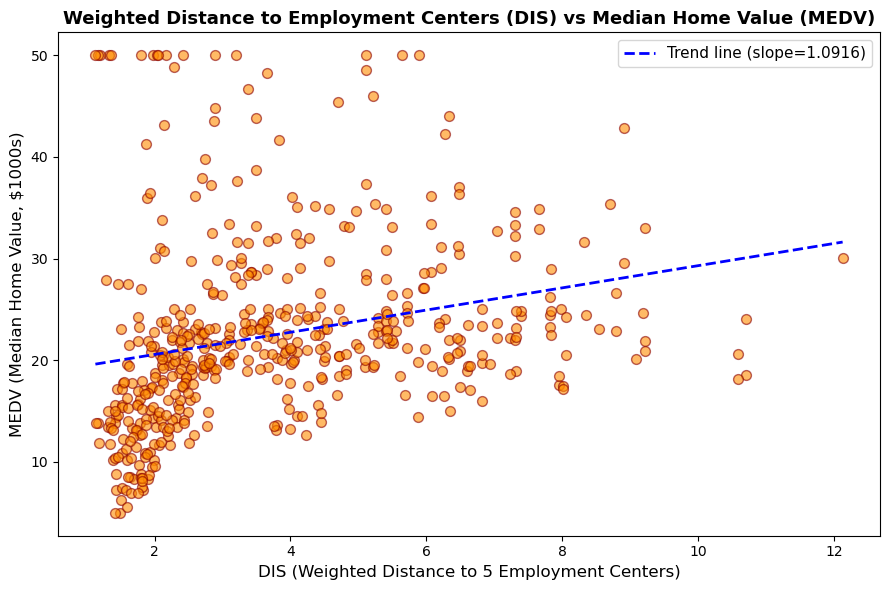

In [53]:
# Scatter plot — DIS vs MEDV
plt.figure(figsize=(9, 6))
plt.scatter(boston_df['dis'], boston_df['medv'], alpha=0.6, color='darkorange', edgecolors='darkred', s=50)

# Trend line
m2, b2 = np.polyfit(boston_df['dis'], boston_df['medv'], 1)
plt.plot(sorted(boston_df['dis']), [m2*x + b2 for x in sorted(boston_df['dis'])],
         color='blue', linewidth=2, linestyle='--', label=f'Trend line (slope={m2:.4f})')

plt.title('Weighted Distance to Employment Centers (DIS) vs Median Home Value (MEDV)', fontsize=13, fontweight='bold')
plt.xlabel('DIS (Weighted Distance to 5 Employment Centers)', fontsize=12)
plt.ylabel('MEDV (Median Home Value, $1000s)', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('scatter_dis_medv.png', dpi=150)
plt.show()

In [54]:
# Question 18: Linear Regression — DIS vs MEDV
# The slope represents the change in MEDV for each unit increase in DIS.

slope, intercept, r_value, p_value, std_err = stats.linregress(boston_df['dis'], boston_df['medv'])

print('=== Linear Regression: DIS → MEDV ===')
print(f'Slope (β1):     {slope:.4f}')
print(f'Intercept (β0): {intercept:.4f}')
print(f'R² value:       {r_value**2:.4f}')
print(f'P-value:        {p_value:.6f}')
print(f'Standard Error: {std_err:.4f}')
print()
print('Equation: MEDV = {:.4f} + {:.4f} * DIS'.format(intercept, slope))
print()
print('Interpretation of Slope:')
print(f'For every 1-unit increase in weighted distance to employment centers (DIS),')
print(f'the median home value (MEDV) increases by approximately ${slope:.2f}K.')
print()
print('This is a positive relationship — homes further from industrial employment')
print('centers tend to have higher values, likely due to lower pollution and more')
print('residential/suburban character of distant neighborhoods.')

=== Linear Regression: DIS → MEDV ===
Slope (β1):     1.0916
Intercept (β0): 18.3901
R² value:       0.0625
P-value:        0.000000
Standard Error: 0.1884

Equation: MEDV = 18.3901 + 1.0916 * DIS

Interpretation of Slope:
For every 1-unit increase in weighted distance to employment centers (DIS),
the median home value (MEDV) increases by approximately $1.09K.

This is a positive relationship — homes further from industrial employment
centers tend to have higher values, likely due to lower pollution and more
residential/suburban character of distant neighborhoods.


---
## Summary of Key Insights

| Insight | Finding |
|---|---|
| **1. Charles River** | Homes bounded by the river have significantly higher median values (T-test: p < 0.05) |
| **2. Housing Age** | Newer housing stock correlates with higher MEDV; confirmed by ANOVA (p < 0.05) |
| **3. NOX vs INDUS** | Strong positive correlation (r ≈ 0.76) — more industrial land → more pollution |
| **4. DIS vs MEDV** | Positive slope in linear regression — greater distance from employment → higher home values |

**Recommendation to Management:** Focus investment in areas near the Charles River, prioritize newer housing developments, address pollution in high-INDUS zones, and recognize that suburban distance from industrial centers commands a price premium.